# Introduction

This notebook is dedicated to fitting experimental Ramsey data using a Master equation that incorporates both magnetic and electric noise. The decay observed in the data typically follows the form $(1/T_2^*)^{exponent}$. The goal is to find both values for $T_2^*$ and the $exponent$ for electric and magnetic noise. By modeling this decay, we can gain insights into the underlying noise processes affecting the system.

# Imports

In [2]:
import sys
import os
sys.path.insert(0, os.path.join('..', 'src'))

import numpy as np
from lmfit import Model, Parameters, minimize
import matplotlib.pyplot as plt
import qcodes as qc
import qutip as qt
import lmfit as lm
from spin import Spin
from noise import get_collapse_operators
from operations import subspace_rotation_operator
from fit_toolbox import ExponentialSineFit, ExponentialFit
from qcodes_loop.data.data_set import load_data


# Build model

This section sets up the model parameters and prepares the data for fitting. 

In [3]:
nucleus = Spin(I=7/2)
Ix, Iy, Iz = nucleus.get_spin_operators()

In [4]:
# Static Hamiltonian: zero (working in the generalised rotating frame)
H0 = Iz*0

def fidelity_decay(psi0s, times, c_ops):
    fidelity = np.zeros([len(psi0s), len(times)], dtype=float)
    T2s = np.zeros(len(psi0s))
    alphas = np.zeros(len(psi0s))
    for p, psi0 in enumerate(psi0s):
        result = qt.mesolve(H0, psi0, times, c_ops, options=qt.Options(nsteps=200000))
        exp_res = qt.expect(psi0 * psi0.dag(), result.states)  # overlap with initial state
        fidelity[p] = exp_res
        result = ExponentialFit(fidelity[p], xvals=times)
        T2s[p] = result.parameters['tau']
        alphas[p] = result.parameters['exponent_factor']
    return fidelity, T2s, alphas

def plot_free_decay(fidelity, T2s):
    kw = {'wspace': 0.4}
    fig, ax = plt.subplots(1, 2, figsize=(8, 2.5), dpi=300, gridspec_kw=kw)
    pcm = ax[0].pcolor(times * 1e3, np.arange(len(fidelity)), fidelity)
    ax[0].set_xlabel('time (ms)')
    ax[0].set_ylabel('Transition index')
    plt.colorbar(pcm, ax=ax[0], label=r'$\langle \psi_0 | \rho | \psi_0 \rangle$')

    for t in range(len(T2s)):
        ax[0].plot([T2s[t] * 1e3, T2s[t] * 1e3], [t - 0.4, t + 0.4], '-', color='tab:red')

    ax[1].plot(np.arange(len(fidelity)), T2s * 1e3, '.', label='Sim', zorder=10)
    ax[1].set_ylim([0, tmax * 1e3])
    ax[1].legend()
    ax[1].set_ylabel('Dephasing time (ms)')
    ax[1].set_xlabel('Transition index')

In [5]:
# noise model parameters
exponent_e = 1.2
exponent_m = 1.60449971294319
T2_star_m = 200e-3
T2_star_e = 300e-3
c_ops = get_collapse_operators(I=7/2, T2_star_m=T2_star_m, exponent_m=exponent_m, T2_star_e=T2_star_e, exponent_e=exponent_e)

# m=1 ramsey (free decay)

In [6]:
dt = 2e-3                     # sampling period 20ms
tmax = 400e-3                 # total time perform experiment,
times = np.arange(0,tmax,dt)
psi0s = []
for i in range(7):
    psi0s.append((qt.basis(8, i) + qt.basis(8, i+1)).unit())

fidelity, T2s, alphas = fidelity_decay(psi0s, times, c_ops)

c:\Users\z5380600\AppData\Local\anaconda3\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


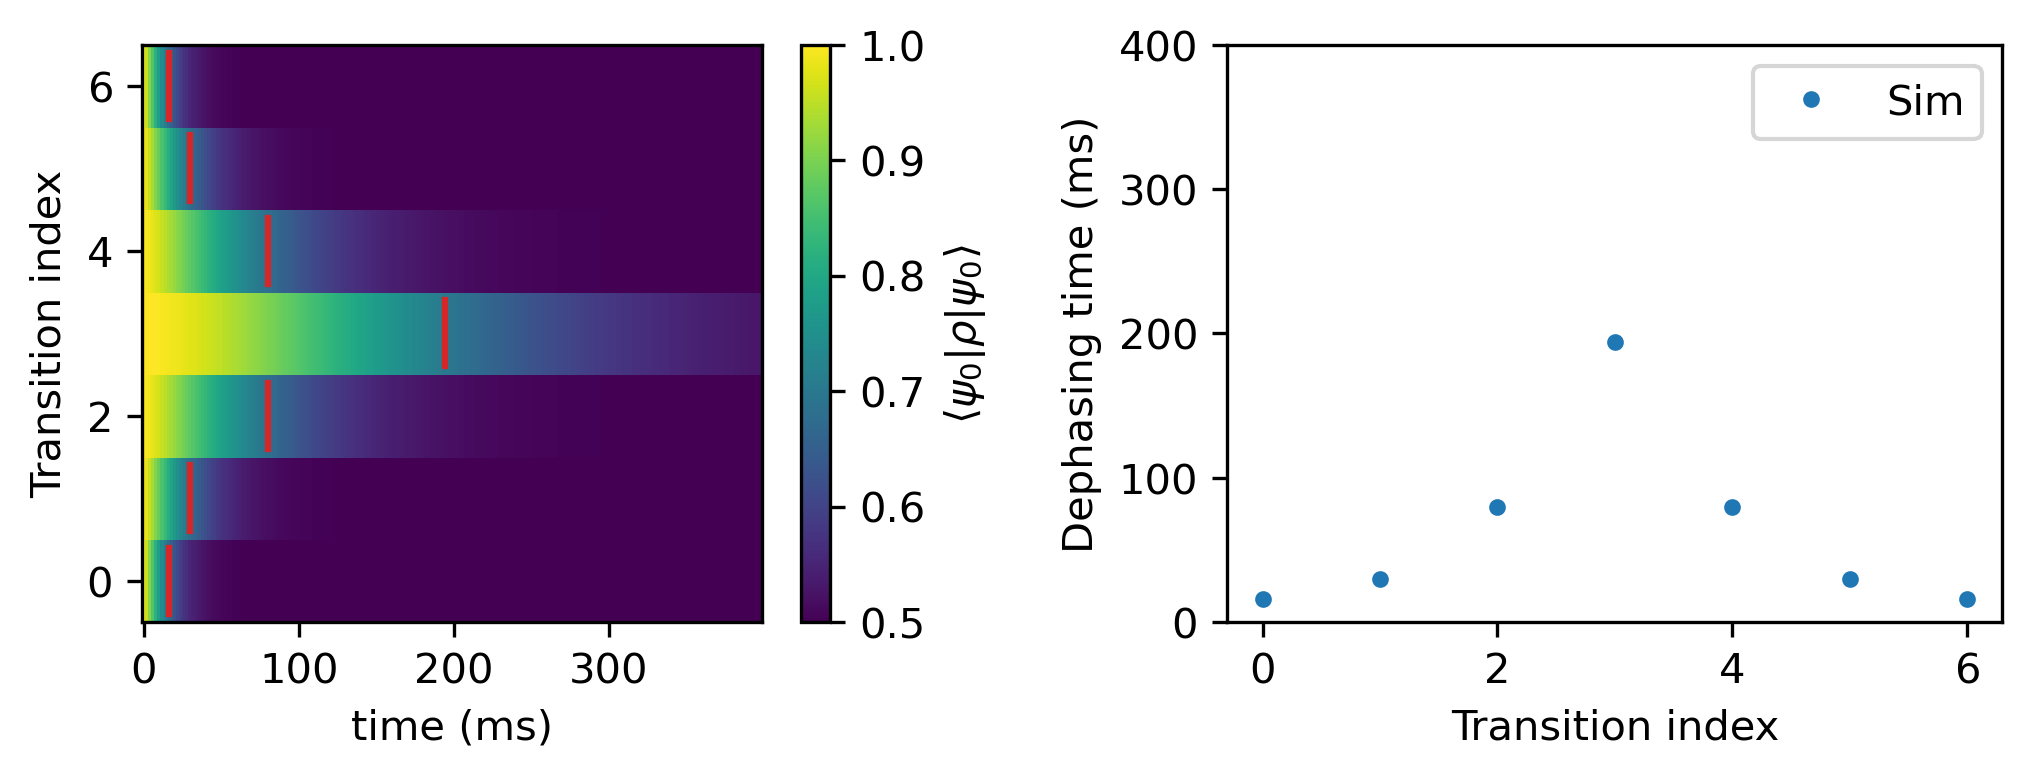

In [7]:
plot_free_decay(fidelity, T2s)

# z-cat states

In [8]:
psi0s = [(qt.basis(8, 3) + qt.basis(8, 4)).unit(),
         (qt.basis(8, 2) + qt.basis(8, 5)).unit(),
         (qt.basis(8, 1) + qt.basis(8, 6)).unit(),
         (qt.basis(8, 0) + qt.basis(8, 7)).unit(),
]

fidelity_zcat = np.zeros([len(psi0s), len(times)], dtype=float)
T2s = np.zeros(len(psi0s))

fidelity_zcat, T2s, alphas = fidelity_decay(psi0s, times, c_ops)

Text(0.5, 1.0, 'z-cat')

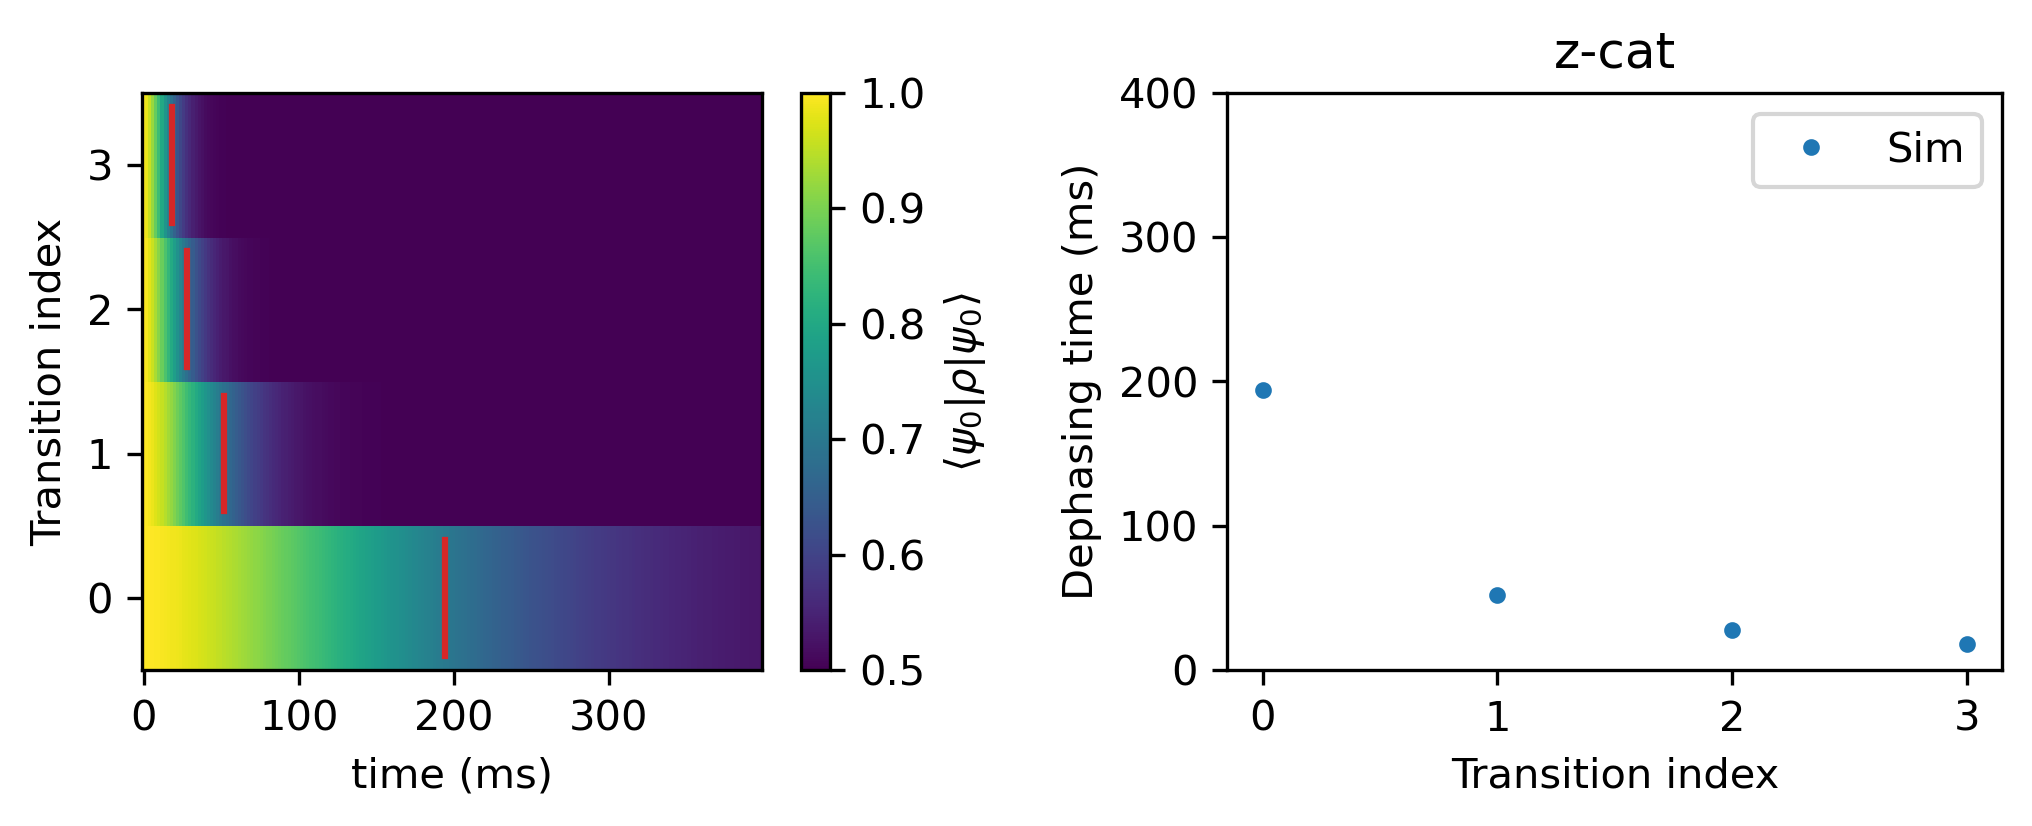

In [9]:
T2s_zdata = np.flip(np.array([17.7, 33.5, 83.7, 233]))*1e-3

plot_free_decay(fidelity_zcat, T2s)
plt.title('z-cat')

# x-cat states

In [10]:
# initial states rotated into the x-basis via a pi/2 rotation around y
ny = np.array([0, 1, 0])
nx = np.array([1, 0, 0])
psi0s = [
    qt.Qobj(subspace_rotation_operator(1/2, np.pi/2, ny)) * (qt.basis(8, 3) + qt.basis(8, 4)).unit(),
    qt.Qobj(subspace_rotation_operator(3/2, np.pi/2, ny)) * (qt.basis(8, 2) + qt.basis(8, 5)).unit(),
    qt.Qobj(subspace_rotation_operator(5/2, np.pi/2, ny)) * (qt.basis(8, 1) + qt.basis(8, 6)).unit(),
    qt.Qobj(subspace_rotation_operator(7/2, np.pi/2, ny)) * (qt.basis(8, 0) + qt.basis(8, 7)).unit(),
]

In [11]:
fidelity = np.zeros([len(psi0s), len(times)], dtype=float)
T2s = np.zeros(len(psi0s))
times = np.linspace(0, 500e-3, 101)  # Example time points

fidelity, T2s, alphas = fidelity_decay(psi0s, times, c_ops)

Text(0.5, 1.0, 'x-cat')

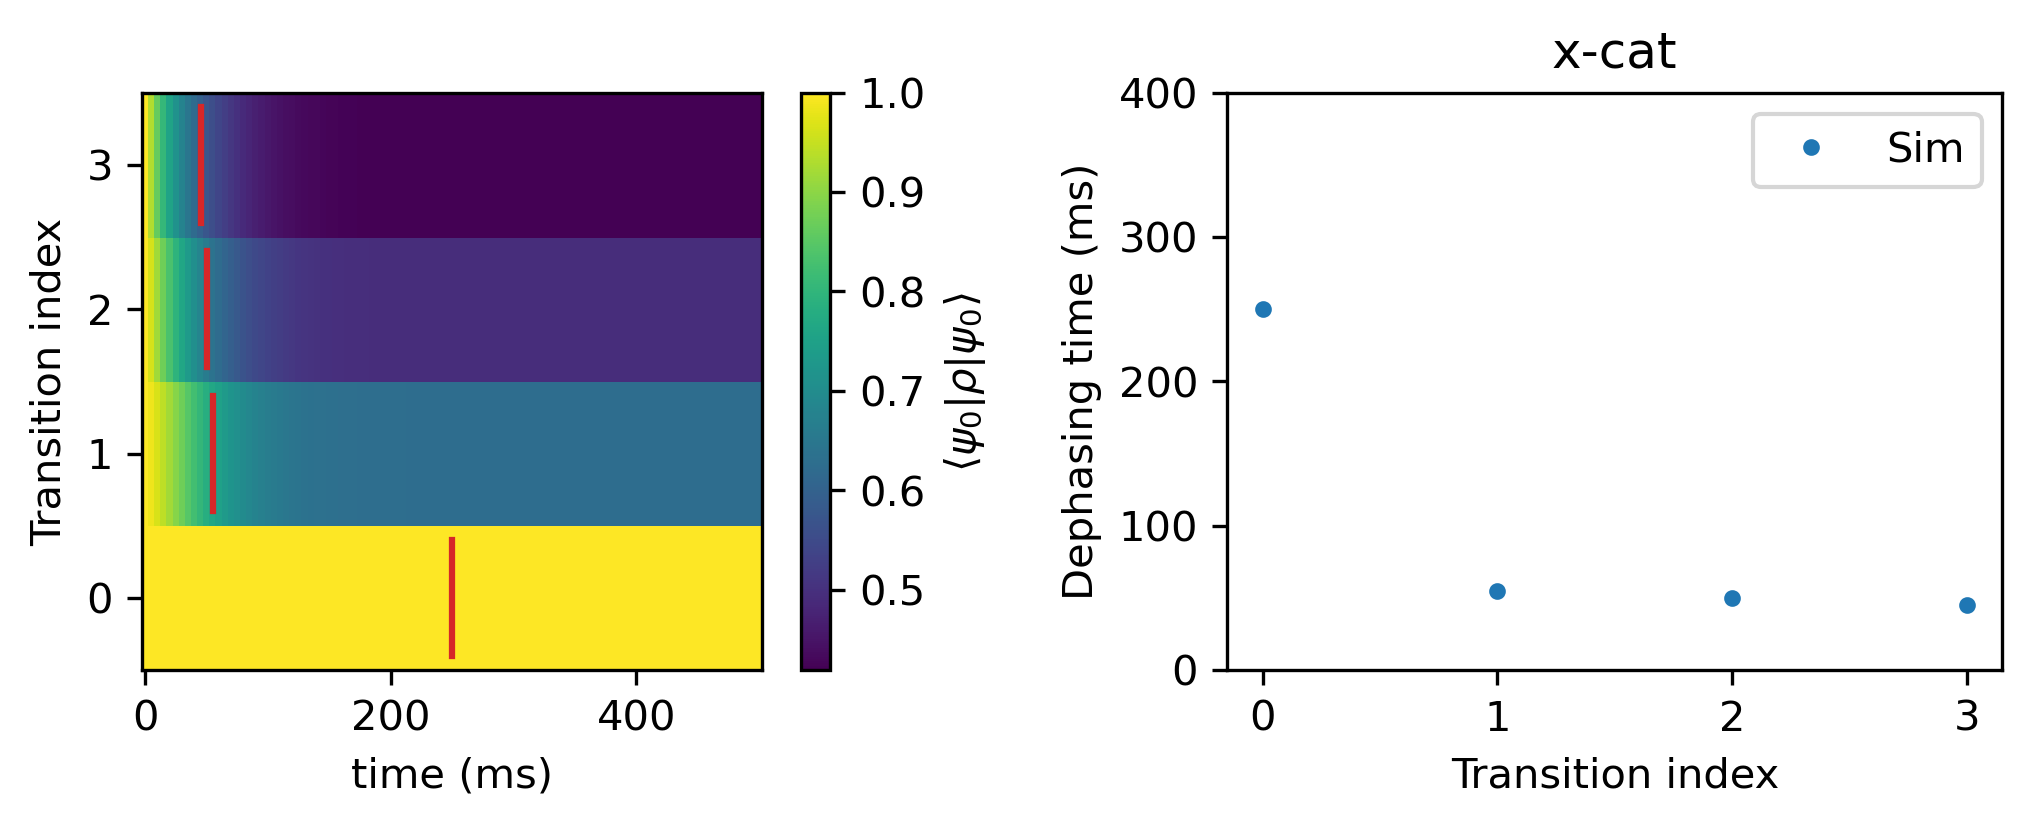

In [12]:
T2s_xdata = np.flip(np.array([46.19, 107.7, 150.8, 233]))*1e-3

plot_free_decay(fidelity, T2s)
plt.title('x-cat')

# Fit data to extract T2*s

In [13]:
def exponential_decay(t, T2star, amplitude, offset, alpha):
    return amplitude * np.exp(-(t / T2star)**alpha) + offset

exp_model = Model(exponential_decay)
params = Parameters()
params.add('T2star', value=1.0, min=0.1, max=1000.0)
params.add('amplitude', value=1.0, min=0.1)
params.add('offset', value=0.0)
params.add('alpha', value=1.0, min=0.1, max=2.0)

In [14]:
NMR_transition_labels = [
    r"$-7/2 \leftrightarrow -5/2$",
    r"$-5/2 \leftrightarrow -3/2$",
    r"$-3/2 \leftrightarrow -1/2$",
    r"$-1/2 \leftrightarrow +1/2$",
    r"$+1/2 \leftrightarrow +3/2$",
    r"$+3/2 \leftrightarrow +5/2$",
    r"$+5/2 \leftrightarrow +7/2$"
]

## Fit m=1 ramsey and z cats

### process m=1 ramsey data

if qc.load_data() doesn't work, try qcodes_loop.data.data_set.load_data(). qc.load_data is depricated in newer versions of QCodes

In [15]:
base_folder = r"C:\Users\z5380600\UNSW\Scarlett - General\data/"
data_T2 = load_data(base_folder + r'2024-01-01\#005_ionized-nmr-ramsey_20-26-23')

In [16]:
NMR_transitions = {
    0: r"$-7/2 \leftrightarrow -5/2$",
    1: r"$-5/2 \leftrightarrow -3/2$",
    2: r"$-3/2 \leftrightarrow -1/2$",
    3: r"$-1/2 \leftrightarrow +1/2$",
    4: r"$+1/2 \leftrightarrow +3/2$",
    5: r"$+3/2 \leftrightarrow +5/2$",
    6: r"$+5/2 \leftrightarrow +7/2$"
}

T2_dict = {}

tau = data_T2.Wait_Time_0_0_0[0][0]

In [23]:
def fit_two_level_ramseys(exponents, plot=False):
    T2s = np.zeros(7)
    T2s_err = np.zeros(7)

    constraints = {
        'tau':            {'min': 0.02, 'max': 0.4},
        'amplitude':      {'min': 0.4,  'max': 0.6},
        'frequency':      {'min': 30,   'max': 80},
        'phase':          {'min': -np.pi, 'max': np.pi},
        'offset':         {'min': 0.3,  'max': 0.7},
        'exponent_factor':{'min': 0.5,  'max': 2.5},
    }

    for s in range(len(data_T2.target_state_0)):
        data_subspace = np.nanmean(data_T2.filtered_flip_probability_0_1_0_0_0_1[s], axis=0)
        t = data_T2.Wait_Time_0_0_0[0][s]

        result = ExponentialSineFit(
            data_subspace, xvals=t,
            initial_parameters={'tau': 0.1, 'exponent_factor': exponents[s]},
            parameter_constraints=constraints,
        )
        T2s[s] = result['tau']
        T2s_err[s] = result.fit_result.params['tau'].stderr

        if plot:
            plt.figure(figsize=(3, 2))
            plt.plot(t, result(t))
            plt.plot(t, data_subspace, '.')
            plt.xlabel('wait time (ms)')
            plt.ylabel('parity contrast')
            plt.title(NMR_transitions[s])

    return T2s, T2s_err

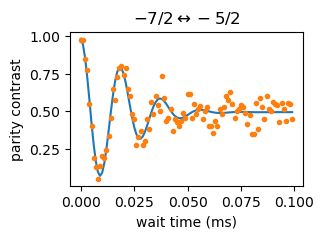

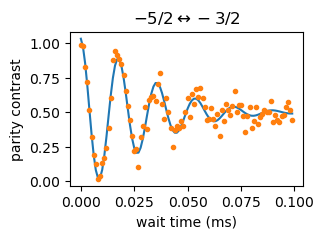

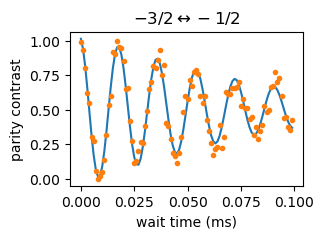

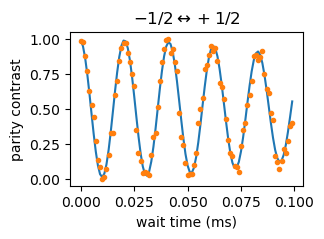

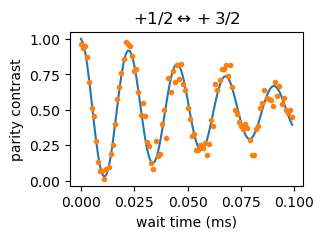

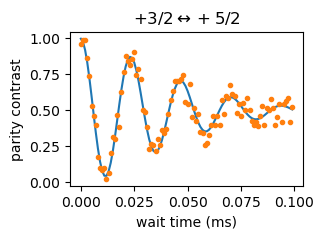

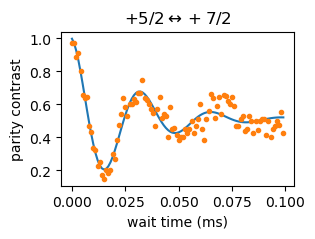

In [24]:
T2s, T2s_err = fit_two_level_ramseys(exponents=np.repeat(1.4, 7), plot=True)

### process z-cat data

In [25]:
data_z_cat_lifetime_7 = load_data(base_folder + r'2023-12-29\#012_ionized-cat-coherence-generalized-ramsey_17-49-09') # 7/2 -7/2 inside
data_z_cat_lifetime_5 = load_data(base_folder + r'2023-12-31\#009_ionized-cat-coherence-generalized-ramsey_13-46-19') # 5/2 -5/2 inside
data_z_cat_lifetime_3 = load_data(base_folder + r'2023-12-31\#008_ionized-cat-coherence-generalized-ramsey_11-25-47') # 3/2 -3/2 inside
data_z_cat_lifetime_1 = load_data(base_folder + r'2023-12-31\#015_ionized-cat-coherence-generalized-ramsey_18-59-39') # 1/2 -1/2 inside

data_z_cat = [data_z_cat_lifetime_7, data_z_cat_lifetime_5, data_z_cat_lifetime_3, data_z_cat_lifetime_1]

# Evaluate State probabilities

cat_list_dict = {
    "0" : "-7/2 to +7/2", 
    "1" : "-5/2 to +5/2", 
    "2" : "-3/2 to +3/2", 
    "3" : "-1/2 to +1/2", }
filter_outside_subspace = True
lifetimes = []
for data_index in range(len(data_z_cat)):    
    data = data_z_cat[data_index]
    num_esr_lines = len(data.ESR_up_proportions_0_0_0_0_0_0[0][0][0])
    state_probabilities = np.zeros((len(data.Wait_Time_0_0_0[0][0]),
                                    len(data.ESR_up_proportions_0_0_0_0_0_0[0][0][0])))
    state_probabilities_std = np.zeros(np.shape(state_probabilities))
    
    exp_values_Iz =  np.zeros((len(data.Wait_Time_0_0_0[0][0])))
    exp_values_Iz_std = np.zeros(np.shape(exp_values_Iz))
    
    num_reps = len(data.ESR_up_proportions_0_0_0_0_0_0[0] )
    
    num_samples = len(data.ESR_up_proportions_0_0_0_0_0_0[0][0][0][0])
    Iz = qt.jmat(7/2, "z")
    Iz_diagonal = np.real(np.diag(Iz.full()))
    
    for i in range(len(data.Wait_Time_0_0_0[0][0])):
        state_list_k = np.concatenate( [np.argmax(data.ESR_up_proportions_0_0_0_0_0_0[0][j][i], axis = 0)\
                              for j in range(len(data.ESR_up_proportions_0_0_0_0_0_0[0]))])
        state_list_k_filtered = [n for n in state_list_k if (n<=(num_esr_lines-data_index-1) and  n>=(data_index))]
        if filter_outside_subspace == True:
#             if (len(state_list_k) != len(state_list_k_filtered)): print("Data Filtered")
            state_list_k = state_list_k_filtered
        for k in range(num_esr_lines):
            state_probabilities[i][k] = np.sum([state_list_k] == np.array([k]*len(state_list_k)))/len(state_list_k)
            state_probabilities_std[i][k] =\
                np.std([state_list_k] == np.array([k]*len(state_list_k)))/np.sqrt(len(state_list_k))
        exp_values_Iz[i] = np.sum(Iz_diagonal[[meas for meas in state_list_k]])/len(state_list_k)
        exp_values_Iz_std[i] = np.std(Iz_diagonal[[meas for meas in state_list_k]])/np.sqrt(len(state_list_k))


    lifetimes.append({
        "State Probabilities" : state_probabilities,
        "State Probabilities Error" : state_probabilities_std,
        "Wait time" : data.Wait_Time_0_0_0[0][0],
        "I_z" : exp_values_Iz,
        "I_z Error": exp_values_Iz_std,
        "Artificial Detuning": data.Artificial_Detuning_1[0]
    }
    )

In [26]:
def fit_z_cat_ramseys(exponents, plot=False):
    T2s = np.zeros(len(lifetimes))
    T2s_err = np.zeros(len(lifetimes))

    constraints = {
        'tau':             {'min': 0.01, 'max': 0.4},
        'amplitude':       {'min': 0.4,  'max': 0.6},
        'phase':           {'min': -np.pi, 'max': np.pi},
        'offset':          {'min': 0.4,  'max': 0.6},
        'exponent_factor': {'min': 0.5,  'max': 2.5},
    }

    for s in range(len(lifetimes)):
        tau = lifetimes[s]["Wait time"]
        y = lifetimes[s]["State Probabilities"][:, s]

        result = ExponentialSineFit(
            y, xvals=tau,
            initial_parameters={'tau': 0.1, 'frequency': 80 / (s + 1), 'phase': 0},
            fixed_parameters={'exponent_factor': exponents[s]},
            parameter_constraints={**constraints, 'frequency': {'min': 10, 'max': 120}},
        )
        T2s[s] = result['tau']
        T2s_err[s] = result.fit_result.params['tau'].stderr

        if plot:
            plt.figure(figsize=(3, 2))
            plt.plot(tau * 1e3, result(tau))
            plt.plot(tau * 1e3, y, '.')
            plt.title(r'Spin %d/2' % ((4 - s) * 2 - 1))
            plt.xlabel('Wait time (ms)')
            plt.ylabel('flip probability')

    return T2s, T2s_err

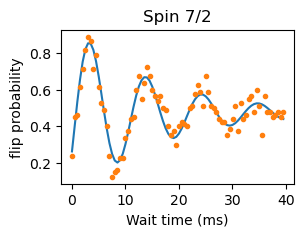

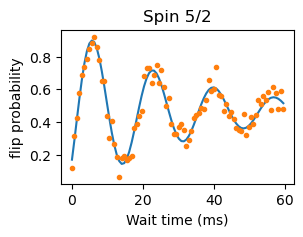

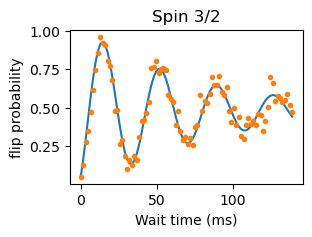

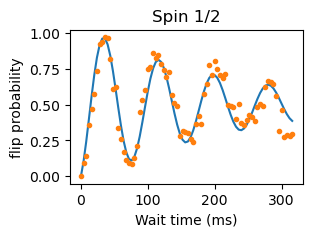

In [29]:
T2s_zcat, T2s_zcat_err = fit_z_cat_ramseys([1,1,1,1], plot=True)

### process x-cat data

In [30]:
data_x_cat_lifetime_7 = load_data(base_folder + r'2023-12-13\#003_Global_Rotation_ionized_generalized_ramsey_13-55-16') # 7/2 -7/2 inside
data_x_cat_lifetime_5 = load_data(base_folder + r'2024-01-25\#006_ionized-cat-coherence_16-52-05') # 5/2 -5/2 inside
data_x_cat_lifetime_3 = load_data(base_folder + r'2024-01-29\#005_ionized-cat-coherence_15-21-26') # 3/2 -3/2 inside
data_x_cat_lifetime_1 = load_data(base_folder + r'2023-12-31\#015_ionized-cat-coherence-generalized-ramsey_18-59-39') # 1/2 -1/2 inside

data_x_cat = [data_x_cat_lifetime_7, data_x_cat_lifetime_5, data_x_cat_lifetime_3, data_x_cat_lifetime_1]

In [31]:
lifetimes_x_cat = []
for data_index in range(len(data_x_cat)):
    data = data_x_cat[data_index]
    num_esr_lines = 8

    try:
        wait_time = data.Wait_Time_0_0_0[0]
        up_proportions = data.ESR_up_proportions_0_0_0_0_0_0[0]
    except:
        wait_time = data.Wait_Time_0_0
        up_proportions = data.ESR_up_proportions_0_0_0_0_0     

    state_probabilities = np.zeros((len(wait_time[0]), len(up_proportions[0][0]) ))
    state_probabilities_std = np.zeros(np.shape(state_probabilities))

    exp_values_Iz = np.zeros(len(wait_time[0]))
    exp_values_Iz_std = np.zeros(np.shape(exp_values_Iz))

    for i in range(len(wait_time[0])):
        state_list_k = np.concatenate( [np.argmax(up_proportions[j][i], axis = 0)\
                              for j in range(len(up_proportions))])
        state_list_k_filtered = [n for n in state_list_k if (n<=(num_esr_lines-data_index-1) and  n>=(data_index))]
        if filter_outside_subspace == True:
            # if (len(state_list_k) != len(state_list_k_filtered)): print("Data Filtered")
            state_list_k = state_list_k_filtered
        for k in range(num_esr_lines):
            state_probabilities[i][k] = np.sum([state_list_k] == np.array([k]*len(state_list_k)))/len(state_list_k)
            state_probabilities_std[i][k] = np.std([state_list_k] == np.array([k]*len(state_list_k)))/np.sqrt(len(state_list_k))
        exp_values_Iz[i] = np.sum(Iz_diagonal[[meas for meas in state_list_k]])/len(state_list_k)
        exp_values_Iz_std[i] = np.std(Iz_diagonal[[meas for meas in state_list_k]])/np.sqrt(len(state_list_k))

    lifetimes_x_cat.append({
        "State Probabilities" : state_probabilities,
        "State Probabilities Error" : state_probabilities_std,
        "I_z" : exp_values_Iz,
        "I_z Error": exp_values_Iz_std,
        "Wait time" : wait_time[0],
            })

In [32]:
def fit_x_cat_ramseys(exponents, plot=False):
    T2s = np.zeros(len(lifetimes_x_cat))
    T2s_err = np.zeros(len(lifetimes_x_cat))

    constraints = {
        'tau':             {'min': 0.01, 'max': 0.4},
        'amplitude':       {'min': 0.5,  'max': 3.5},
        'frequency':       {'min': 10,   'max': 120},
        'phase':           {'min': -np.pi, 'max': np.pi},
        'offset':          {'min': -0.6, 'max': 0.6},
        'exponent_factor': {'min': 0.5,  'max': 1.5},
    }

    for s in range(len(lifetimes_x_cat)):
        tau = lifetimes_x_cat[s]["Wait time"]
        y = lifetimes_x_cat[s]["I_z"]

        result = ExponentialSineFit(
            y, xvals=tau,
            initial_parameters={'tau': 0.16, 'amplitude': np.max(y),
                                 'frequency': 51 / (s + 1), 'phase': -np.pi / 2, 'offset': 0},
            fixed_parameters={'exponent_factor': exponents[s]},
            parameter_constraints=constraints,
        )
        T2s[s] = result['tau']
        T2s_err[s] = result.fit_result.params['tau'].stderr

        if plot:
            plt.figure(figsize=(3, 2))
            plt.plot(tau * 1e3, result(tau))
            plt.plot(tau * 1e3, y, '.')
            plt.title(r'Spin %d/2' % ((4 - s) * 2 - 1))
            plt.xlabel('Wait time (ms)')
            plt.ylabel('flip probability')

    return T2s, T2s_err

(array([0.05716499, 0.10793131, 0.14889533, 0.21166593]),
 array([0.00545576, 0.01455118, 0.0270107 , 0.02506825]))

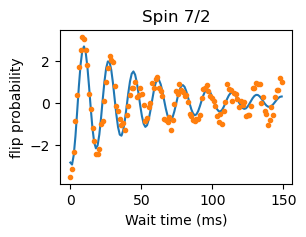

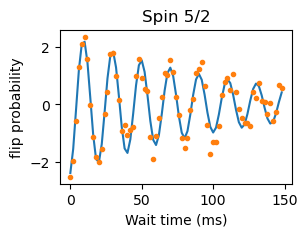

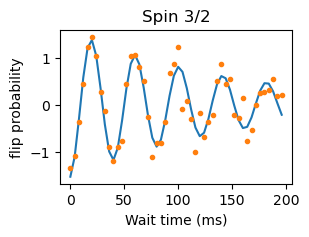

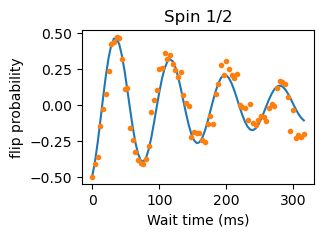

In [33]:
fit_x_cat_ramseys([1,1,1,1.1], plot=True)

The idea of the fitting is to optimize T2* values for both the m=1 ramseys and z-cat ramseys:

- Pick values for T2\*\_m, T2\*\_e, exponent\_m, exponent\_e
- Generate a set of T2\* values from the Ramsey measurement data (both m=1 Ramsey and z-cats) using fixed values for exponent\_m, exponent\_e
- Simulate a set of T2\* values with values for T2\*\_m, T2\*\_e, exponent\_m, exponent\_e (both m=1 and z-cats)
- Concatenate T2\* arrays for m=1 and z-cats, both for data and simulation
- Minimize residual = (data - simulation) with free param

### fitting helpers

In [ ]:
# fitting helpers

def calculate_two_level_T2_exponents(t2star_m, t2star_e, exponent_m, exponent_e, plot=False):
    """
    Calculate the T2* and exponents for the m=1-ramseys based on given parameters.

    This function simulates Ramsey experiments and fits the resulting data to 
    extract T2* times and their exponents for the SO2 ramseys. Optionally, it can plot the 
    fit results for each state.

    Parameters:
    t2star_m (float): T2* time for the magnetic noise.
    t2star_e (float): T2* time for the electric noise.
    exponent_m (float): Exponent for the magnetic noise decay.
    exponent_e (float): Exponent for the electric noise decay.
    plot (bool, optional): If True, plots the fit results for each state. Default is False.

    Returns:
    tuple: A tuple containing:
        - T2 (numpy array): The fitted T2* times for the m=1 ramseys.
        - alphas (numpy array): The exponents for the fitted T2* times.
    """
    
    dt = 2e-3                     # sampling period
    tmax = 500e-3                
    times = np.arange(0,tmax,dt)
    psi0s = []
    for i in range(7):
        psi0s.append((qt.basis(8, i) + qt.basis(8, i+1)).unit())
        
    c_ops = get_collapse_operators(7/2, t2star_m, exponent_m, t2star_e, exponent_e)
    fidelity, T2s, alphas = fidelity_decay(psi0s, times, c_ops)

    if plot:
        plot_free_decay(fidelity, T2s)
        
    return T2s, alphas

def calculate_zcat_T2_exponents(t2star_m, t2star_e, exponent_m, exponent_e, plot=False):
    """
    Calculate the T2* and exponents for the z-cat-ramseys based on given parameters.

    This function uses a high spin model to simulate Ramsey experiments and fit the resulting data to 
    extract T2* times and their exponents for the z-cat ramseys. Optionally, it can plot the 
    fit results for each state.

    Parameters:
    t2star_m (float): T2* time for the magnetic noise.
    t2star_e (float): T2* time for the electric noise.
    exponent_m (float): Exponent for the magnetic noise decay.
    exponent_e (float): Exponent for the electric noise decay.
    plot (bool, optional): If True, plots the fit results for each state. Default is False.

    Returns:
    tuple: A tuple containing:
        - T2_so2 (numpy array): The fitted T2* times for the z-cats.
        - T2_so2_alpha (numpy array): The exponents for the fitted T2* times.
    """
    psi0s = [(qt.basis(8, 3) + qt.basis(8, 4)).unit(),
             (qt.basis(8, 2) + qt.basis(8, 5)).unit(),
             (qt.basis(8, 1) + qt.basis(8, 6)).unit(),
             (qt.basis(8, 0) + qt.basis(8, 7)).unit(),
    ]
    dt = 2e-3                     
    tmax = 500e-3                 
    times = np.arange(0,tmax,dt)
    c_ops = get_collapse_operators(7/2, t2star_m, exponent_m, t2star_e, exponent_e)
    fidelity, T2s, alphas = fidelity_decay(psi0s, times, c_ops)
    if plot:
        plot_free_decay(fidelity, T2s)
        
    return T2s, alphas

def calculate_x_T2_exponents(t2star_m, t2star_e, exponent_m, exponent_e, plot=False):
    """
    Calculate the T2* and exponents for the x-cat-ramseys based on given parameters.

    This function uses a high spin model to simulate Ramsey experiments and fit the resulting data to 
    extract T2* times and their exponents for the x-cat ramseys. Optionally, it can plot the 
    fit results for each state.

    Parameters:
    t2star_m (float): T2* time for the magnetic noise.
    t2star_e (float): T2* time for the electric noise.
    exponent_m (float): Exponent for the magnetic noise decay.
    exponent_e (float): Exponent for the electric noise decay.
    plot (bool, optional): If True, plots the fit results for each state. Default is False.

    Returns:
    tuple: A tuple containing:
        - T2_so2 (numpy array): The fitted T2* times for the x-cats.
        - T2_so2_alpha (numpy array): The exponents for the fitted T2* times.
    """

    nx = np.array([1, 0, 0])
    psi0s = [qt.Qobj(subspace_rotation_operator(1/2, np.pi/2, nx))*(qt.basis(8, 3) + qt.basis(8, 4)).unit(),
             qt.Qobj(subspace_rotation_operator(3/2, np.pi/2, nx))*(qt.basis(8, 2) + qt.basis(8, 5)).unit(),
             qt.Qobj(subspace_rotation_operator(5/2, np.pi/2, nx))*(qt.basis(8, 1) + qt.basis(8, 6)).unit(),
             qt.Qobj(subspace_rotation_operator(7/2, np.pi/2, nx))*(qt.basis(8, 0) + qt.basis(8, 7)).unit(),
    ]
    dt = 2e-3                     # sampling period
    tmax = 500e-3               
    times = np.arange(0,tmax,dt)
    c_ops = get_collapse_operators(7/2, t2star_m, exponent_m, t2star_e, exponent_e)
    fidelity, T2s, alphas = fidelity_decay(psi0s, times, c_ops)
    if plot:
        plot_free_decay(fidelity, T2s)
        
    return T2s, alphas

In [42]:
alphas

array([1., 1., 1., 1.])

In [43]:
T2_sim, alphas = calculate_two_level_T2_exponents(t2star_m=300e-3, t2star_e=500e-3, exponent_m=1.5, exponent_e=1.1, plot=True)
T2_data, T2_err = generate_T2_data(alphas)
plt.plot(T2_data*1e3, '.')

c:\Users\z5380600\AppData\Local\anaconda3\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


ZeroDivisionError: 0.0 cannot be raised to a negative power

In [858]:
psi0s = [subspace_rotation_arb_vec(1/2, np.pi/2, nx)*(qt.basis(8, 3) + qt.basis(8, 4)).unit(),
         subspace_rotation_arb_vec(3/2, np.pi/2, nx)*(qt.basis(8, 2) + qt.basis(8, 5)).unit(),
         subspace_rotation_arb_vec(5/2, np.pi/2, nx)*(qt.basis(8, 1) + qt.basis(8, 6)).unit(),
         subspace_rotation_arb_vec(7/2, np.pi/2, nx)*(qt.basis(8, 0) + qt.basis(8, 7)).unit(),
]

In [859]:
psi0s[-1]

array([[ 0.0625    -0.0625j    ],
       [-0.16535946+0.16535946j],
       [-0.28641098+0.28641098j],
       [ 0.36975499-0.36975499j],
       [ 0.36975499-0.36975499j],
       [-0.28641098+0.28641098j],
       [-0.16535946+0.16535946j],
       [ 0.0625    -0.0625j    ]])

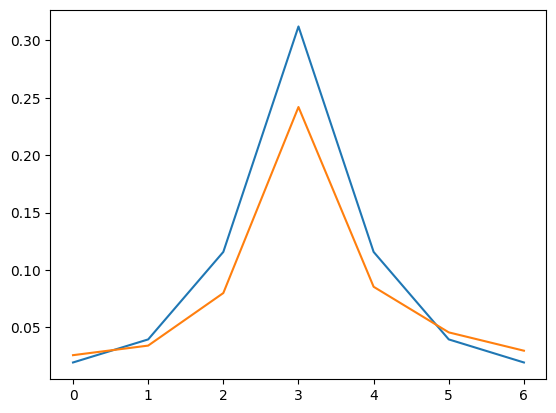

In [813]:
#example for m=1 ramseys
plt.plot(T2_sim)
plt.plot(T2_data)

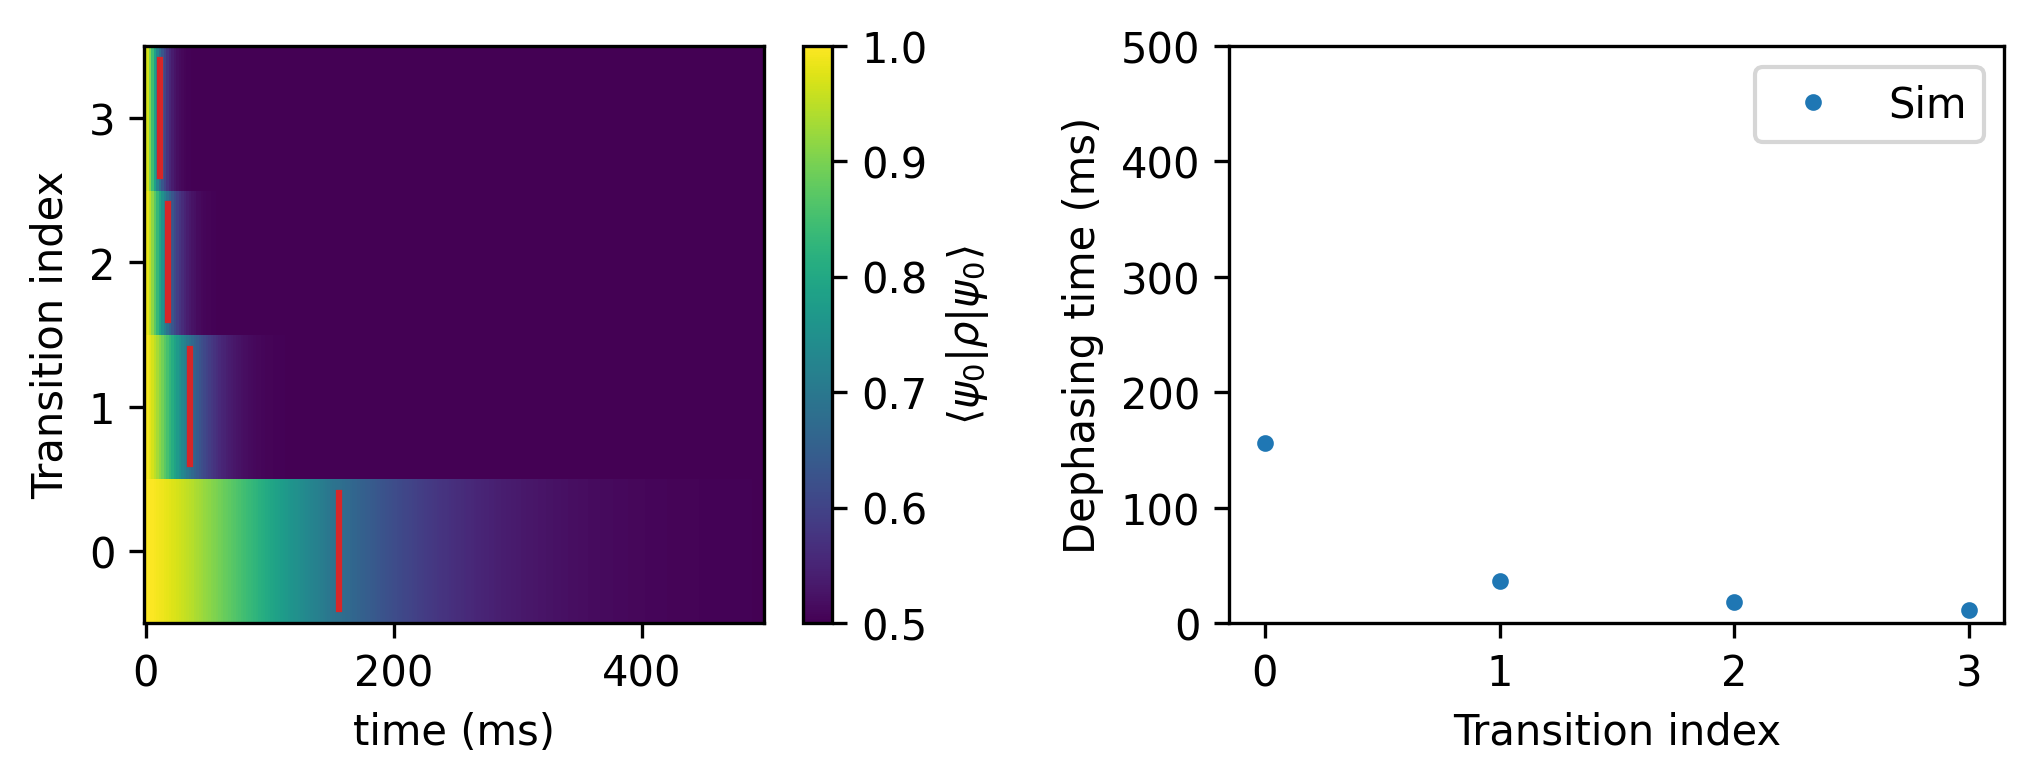

In [814]:
# z-cats example
T2_sim = calculate_z_T2_exponents(t2star_m=150e-3, t2star_e=100e-3, exponent_m=1.5, exponent_e=1.1, plot=True)

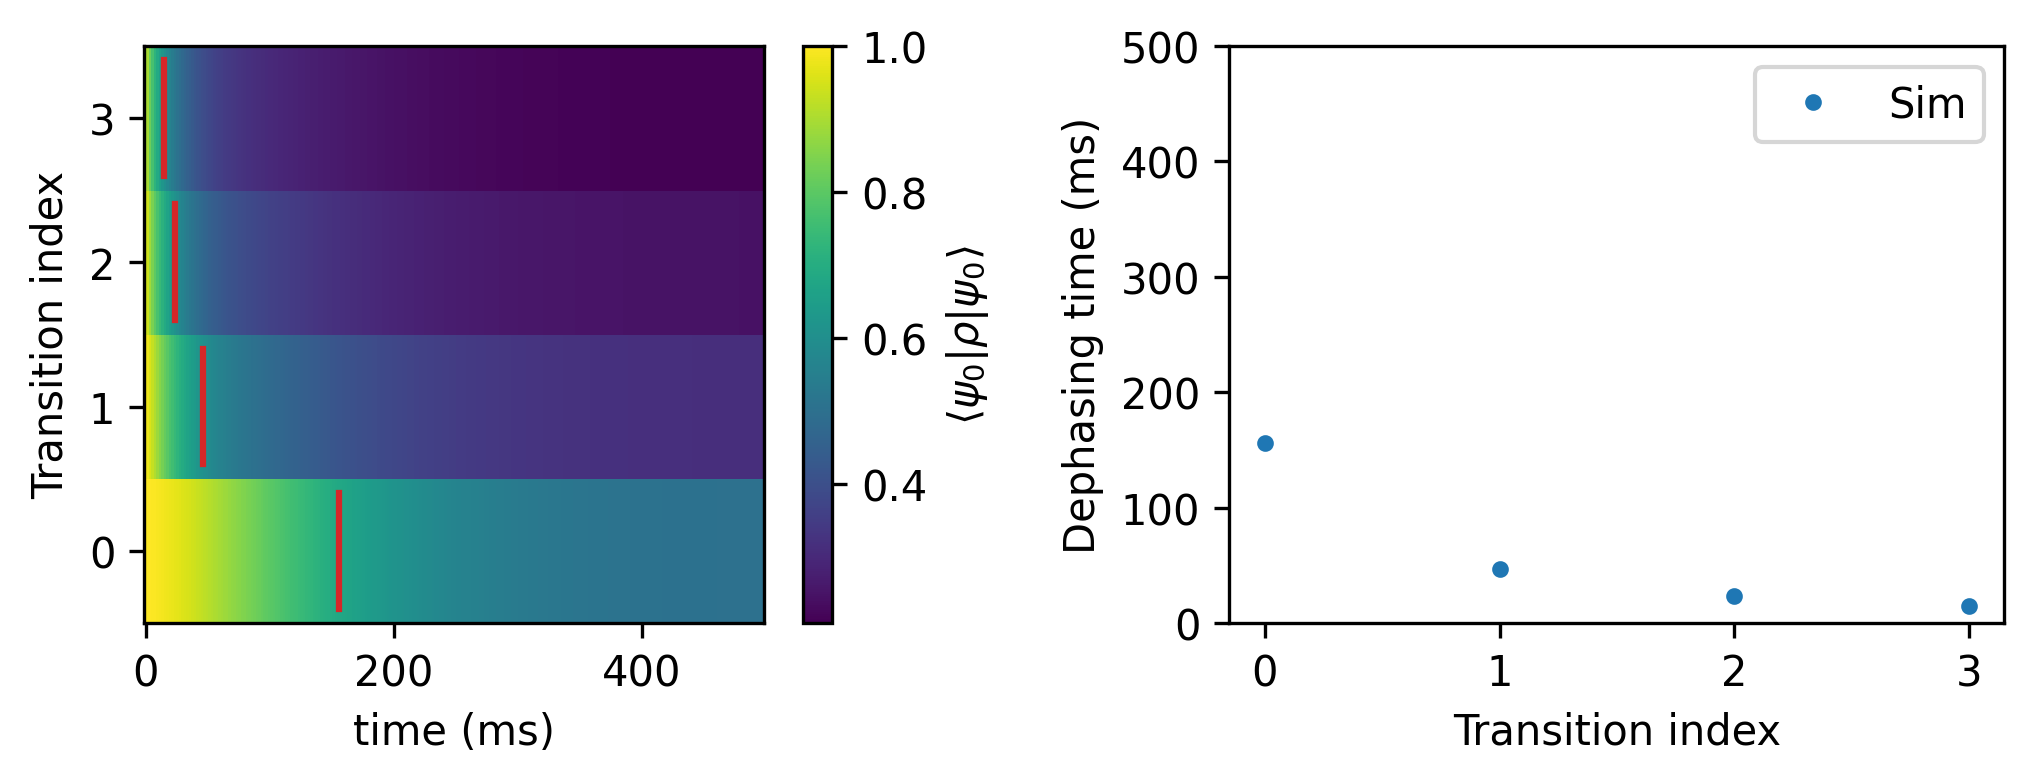

In [815]:
# z-cats example
T2_sim = calculate_x_T2_exponents(t2star_m=150e-3, t2star_e=100e-3, exponent_m=1.5, exponent_e=1.1, plot=True)

### fit

In [854]:
# Define a wrapper function for lmfit
def residual(params):
    t2star_m = params['T2_m'].value
    t2star_e = params['T2_e'].value 
    exponent_m = params['exponent_m'].value 
    exponent_e = params['exponent_e'].value
    
    # m=1
    T2_model, alphas = calculate_so2_T2_exponents(t2star_m, t2star_e, exponent_m, exponent_e)
    T2_data, T2_err = generate_T2_data(alphas)
    
    # cats
    T2_model_z, alphas_z = calculate_z_T2_exponents(t2star_m, t2star_e, exponent_m, exponent_e)
    T2_data_z, T2_err_z = generate_T2_z(alphas_z, plot=False)
    
    T2_model_x, alphas_x = calculate_x_T2_exponents(t2star_m, t2star_e, exponent_m, exponent_e)
    T2_data_x, T2_err_x = generate_T2_x(alphas_x, plot=False)
    
#     # concatenate m=1 ramsey and z-cat states arrays
    model = np.concatenate([T2_model, T2_model_z[:-1], T2_model_x[1:-1]]) # i remove the last element because they are all the -1/2->1/2 superposition
    data = np.concatenate([T2_data, np.flip(T2_data_z)[:-1], np.flip(T2_data_x)[1:-1]])
    
    return (1/model - 1/data)

# Create lmfit Parameters object
fit_params = Parameters()
fit_params.add('exponent_m', value=1.5, min=1.0, max=1.7)
fit_params.add('exponent_e', value=1.4, min=1.0, max=1.7)

fit_params.add('T2_m', value=200-3, min=120e-3, max=250e-3)
fit_params.add('T2_e', value=163e-3, min=100e-3, max=800e-3)

# optimize (this can take a minute)
result = minimize(residual, fit_params, method='nelder-mead')

In [855]:
result

# Visualisation

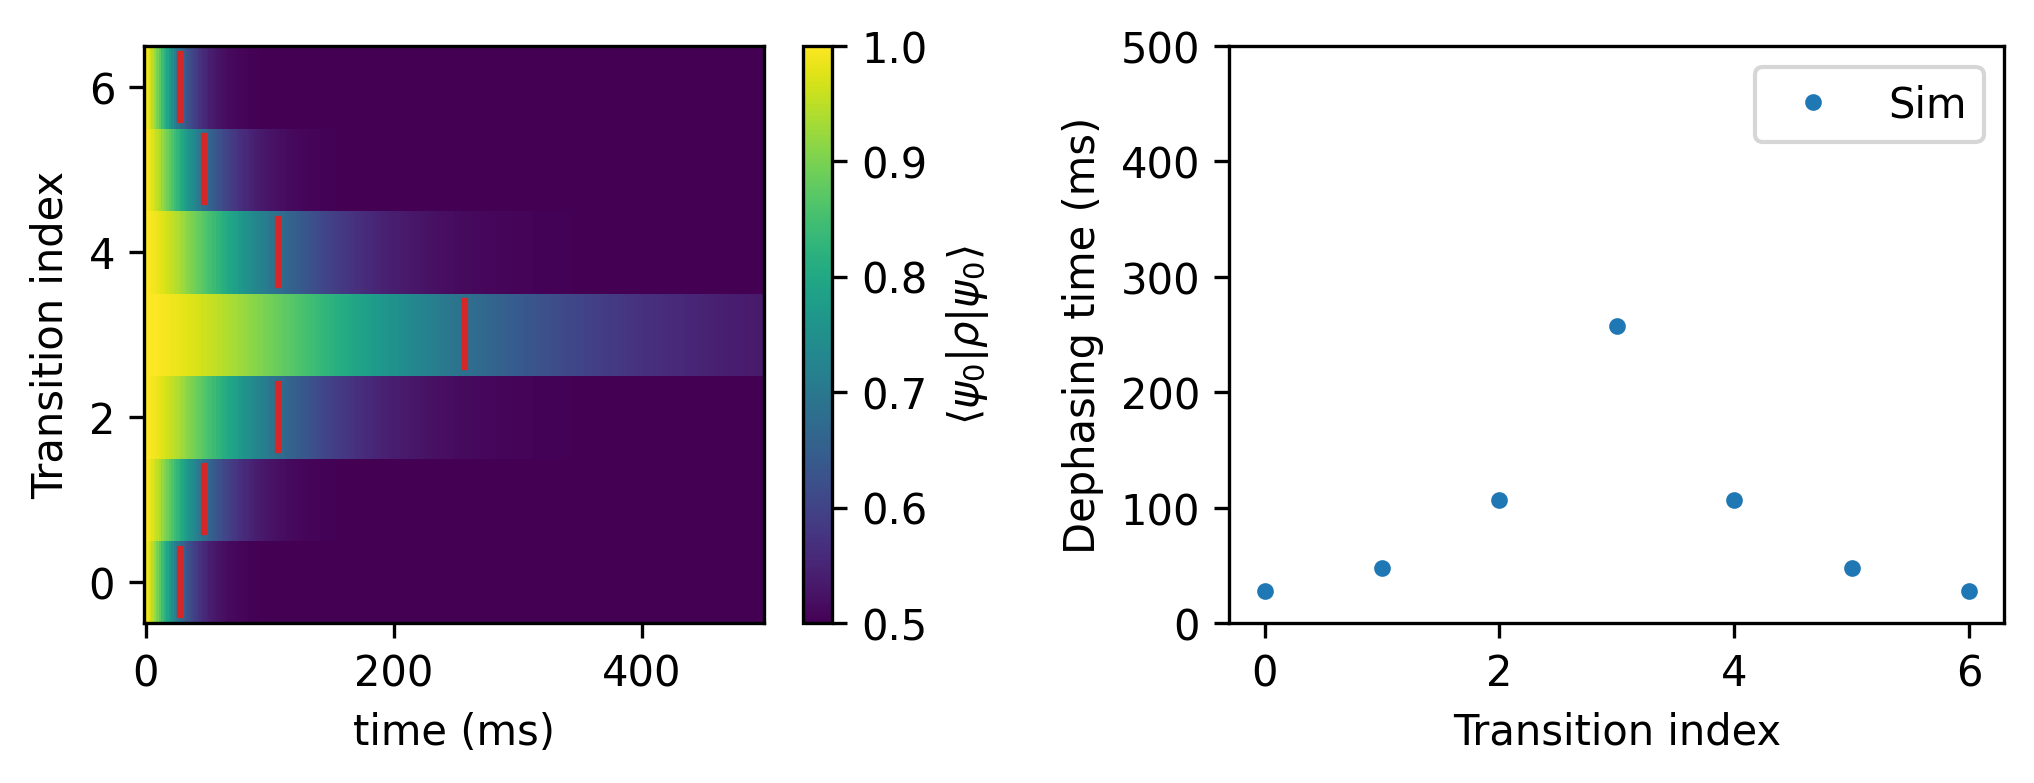

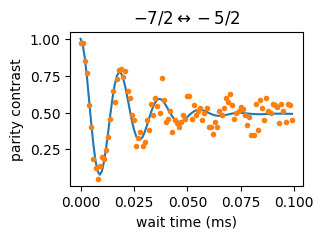

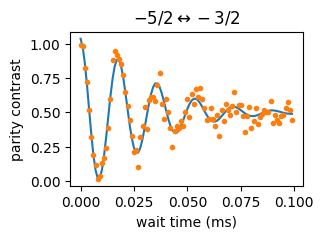

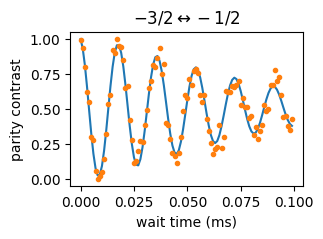

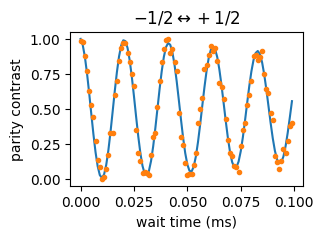

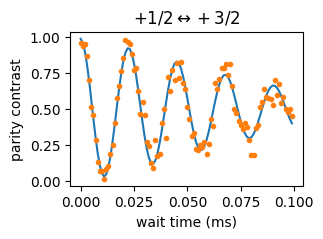

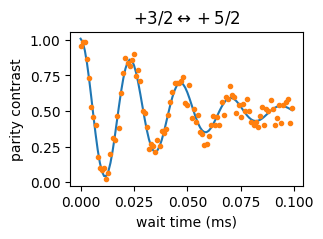

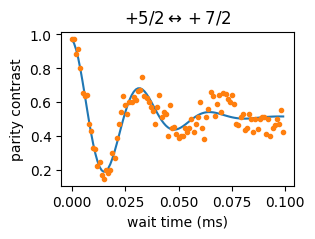

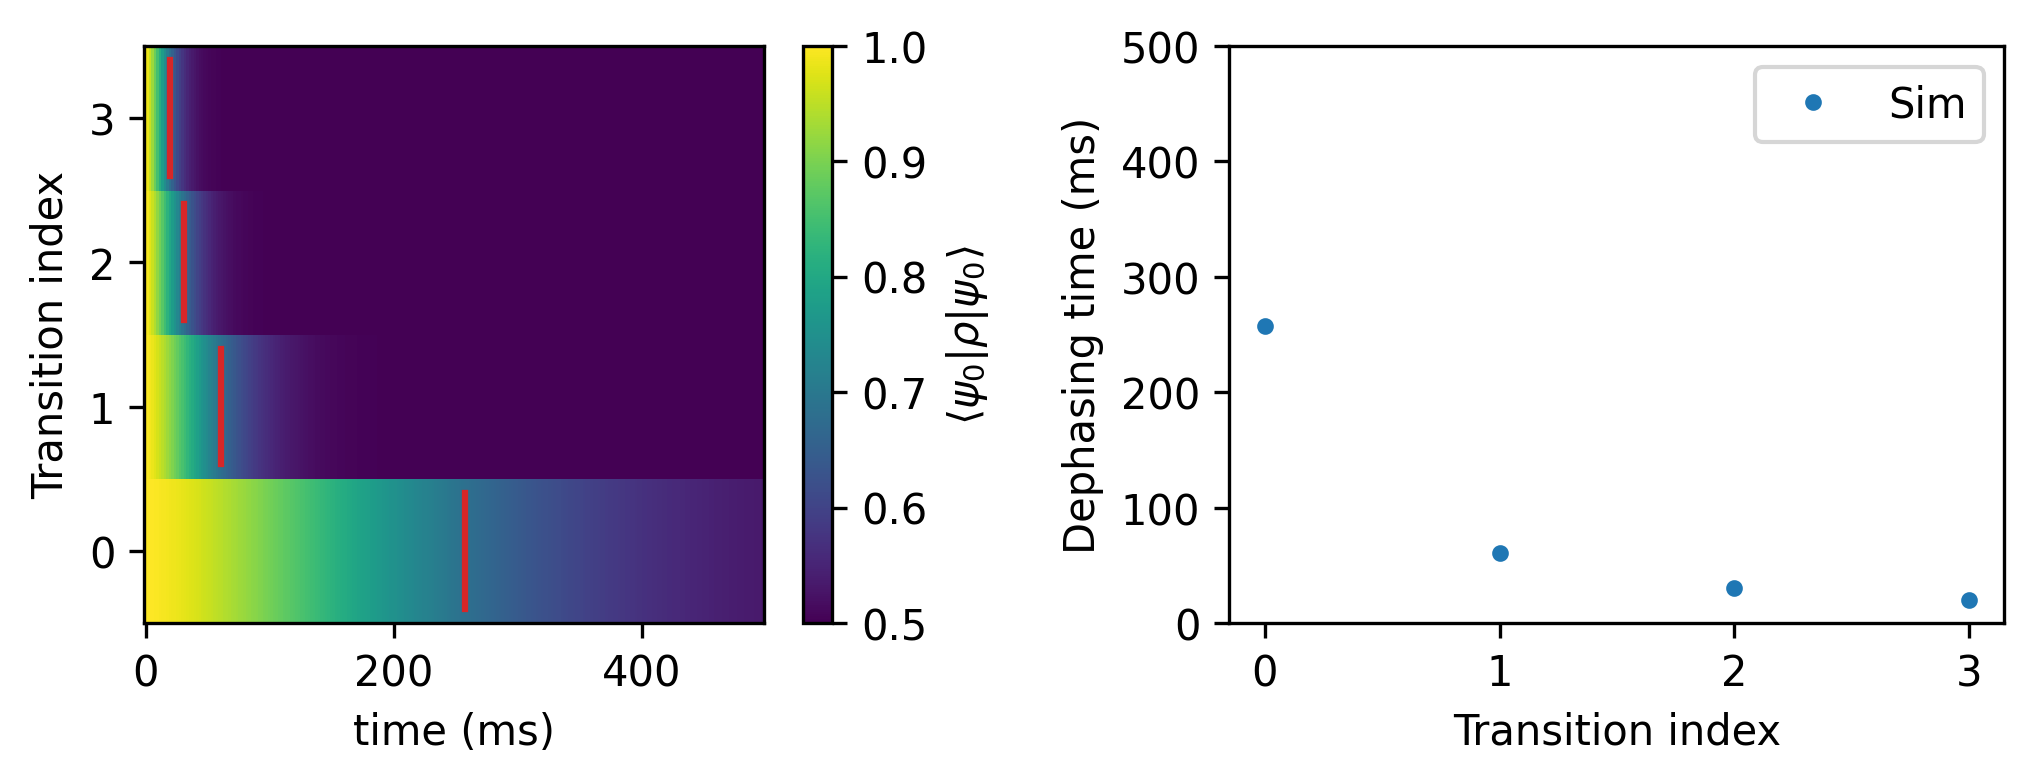

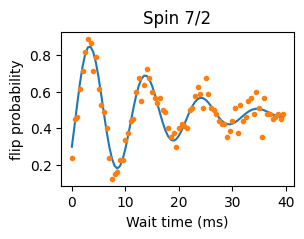

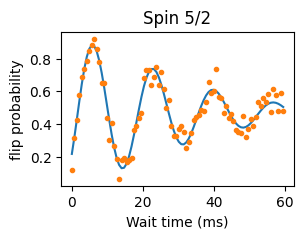

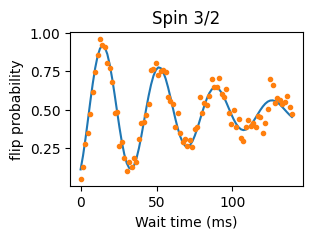

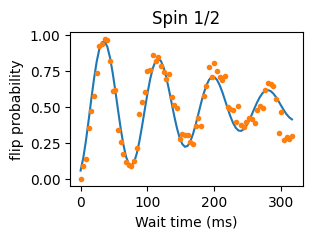

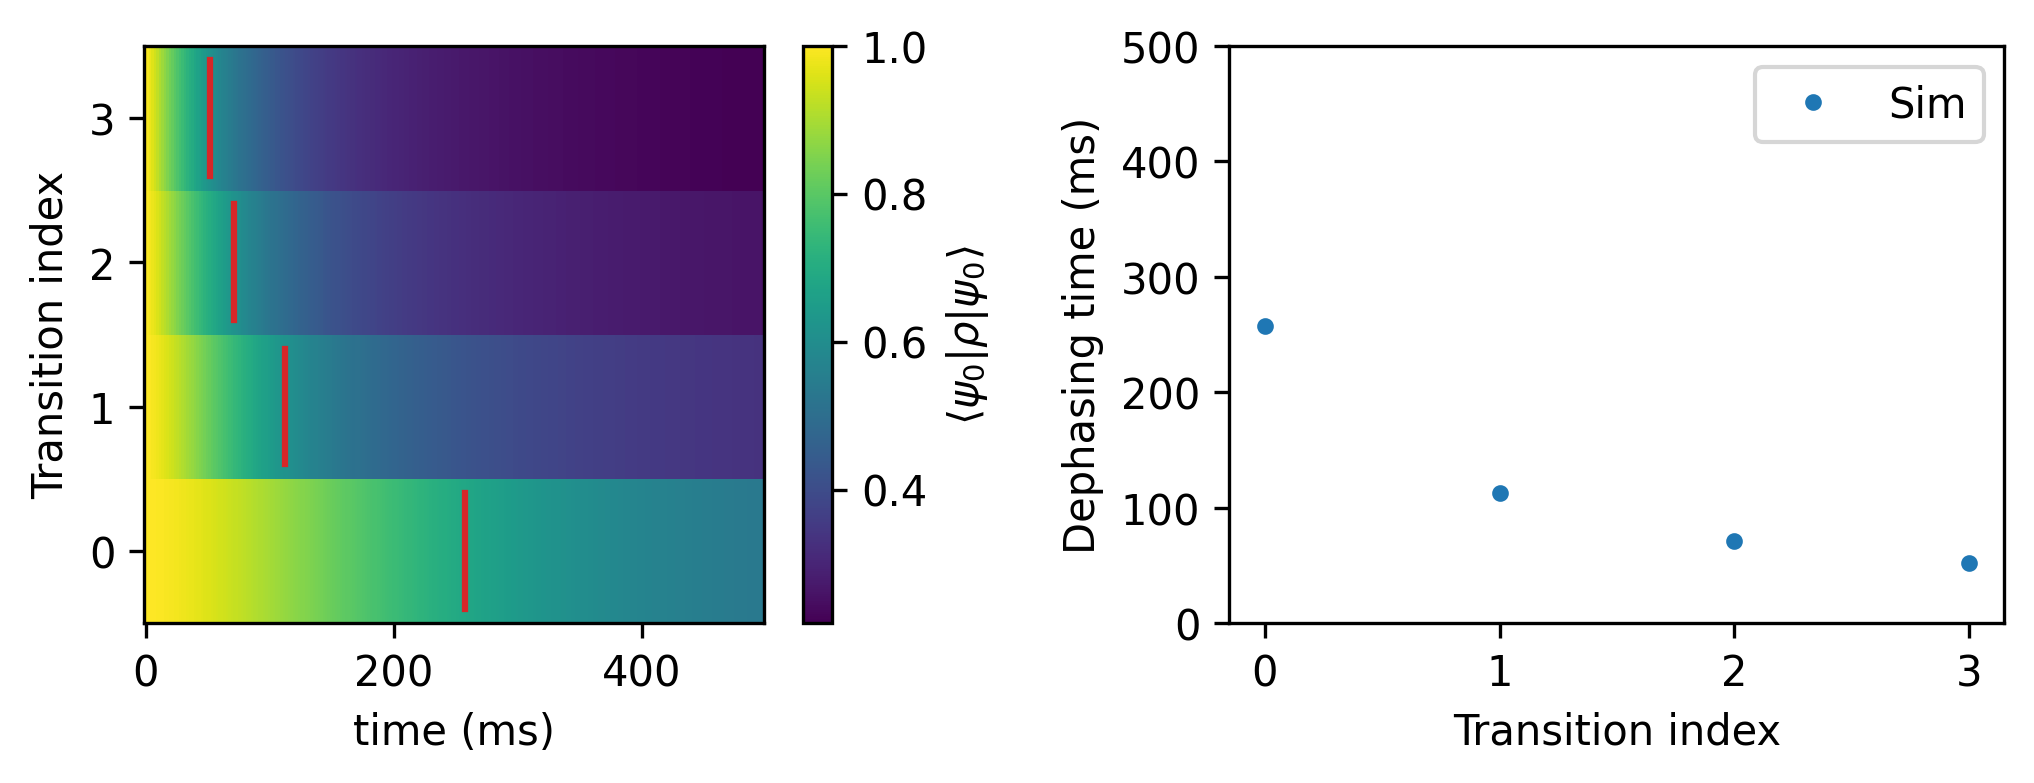

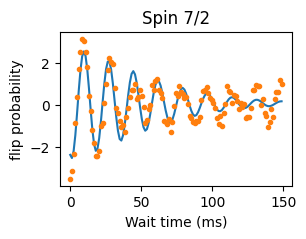

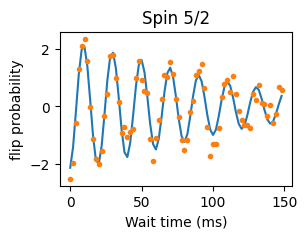

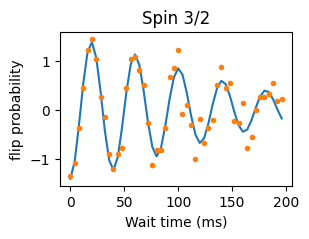

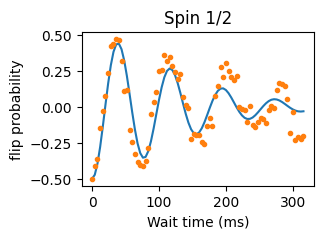

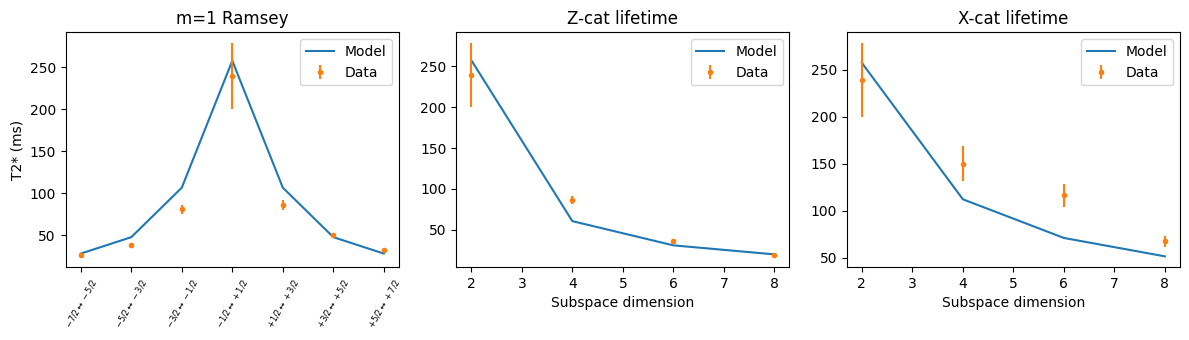

In [856]:
t2star_m = result.params['T2_m']
t2star_e = result.params['T2_e'] 
exponent_m = result.params['exponent_m'] 
exponent_e = result.params['exponent_e']

T2_model, alphas = calculate_so2_T2_exponents(t2star_m, t2star_e, exponent_m, exponent_e, plot=True)
T2_data, T2_err = generate_T2_data(alphas, plot=True)
T2_model_z, alphas_z = calculate_z_T2_exponents(t2star_m, t2star_e, exponent_m, exponent_e, plot=True)
T2_z_data, T2_z_err = generate_T2_z(alphas_z, plot=True)
T2_model_x, alphas_x = calculate_x_T2_exponents(t2star_m, t2star_e, exponent_m, exponent_e, plot=True)
T2_x_data, T2_x_err = generate_T2_x(alphas_x, plot=True)

T2_z_data[-1] = T2_data[3]
T2_z_err[-1] = T2_err[3]

T2_x_data[-1] = T2_data[3]
T2_x_err[-1] = T2_err[3]
# T2_x_err[0] = 0


fig, ax = plt.subplots(1,3,figsize=(12, 3.5))
ax[0].plot(np.arange(7), T2_model*1e3, label='Model')
ax[0].errorbar(np.arange(7), T2_data*1e3, T2_err*1e3, marker='.', label='Data', ls='None')
ax[0].set_xticks(np.arange(7))
ax[0].set_xticklabels(NMR_transition_labels, fontsize = 6, rotation=60)
ax[0].set_title('m=1 Ramsey')
ax[0].set_ylabel('T2* (ms)')
ax[0].legend()

ax[1].plot([2, 4, 6, 8], T2_model_z*1e3, label='Model')
ax[1].errorbar([2, 4, 6, 8], np.flip(T2_z_data)*1e3, np.flip(T2_z_err)*1e3, marker='.', label='Data', ls='None')
ax[1].set_xlabel('Subspace dimension')
ax[1].set_title('Z-cat lifetime')
ax[1].legend()

ax[2].plot([2, 4, 6, 8], T2_model_x*1e3, label='Model')
ax[2].errorbar([2, 4, 6, 8], np.flip(T2_x_data)*1e3, np.flip(T2_x_err)*1e3, marker='.', label='Data', ls='None')
ax[2].set_xlabel('Subspace dimension')

ax[2].set_title('X-cat lifetime')
ax[2].legend()
plt.tight_layout()


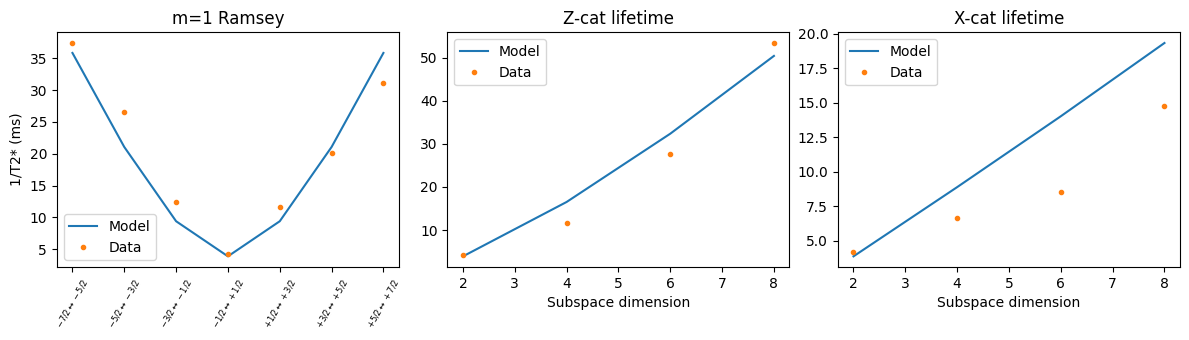

In [857]:
fig, ax = plt.subplots(1,3,figsize=(12, 3.5))
ax[0].plot(np.arange(7), 1/T2_model, label='Model')
ax[0].plot(np.arange(7), 1/T2_data, marker='.', label='Data', ls='None')
ax[0].set_xticks(np.arange(7))
ax[0].set_xticklabels(NMR_transition_labels, fontsize = 6, rotation=60)
ax[0].set_title('m=1 Ramsey')
ax[0].set_ylabel('1/T2* (ms)')
ax[0].legend()

ax[1].plot([2, 4, 6, 8], 1/T2_model_z, label='Model')
ax[1].plot([2, 4, 6, 8], 1/np.flip(T2_z_data), marker='.', label='Data', ls='None')
ax[1].set_xlabel('Subspace dimension')
ax[1].set_title('Z-cat lifetime')
ax[1].legend()

ax[2].plot([2, 4, 6, 8], 1/T2_model_x, label='Model')
ax[2].plot([2, 4, 6, 8], 1/np.flip(T2_x_data), marker='.', label='Data', ls='None')
ax[2].set_xlabel('Subspace dimension')

ax[2].set_title('X-cat lifetime')
ax[2].legend()
plt.tight_layout()

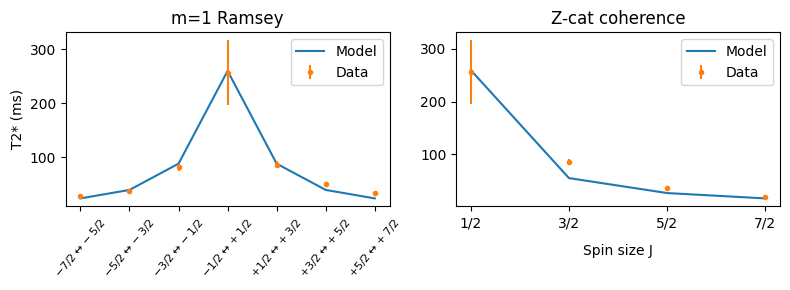

In [126]:
fig, ax = plt.subplots(1,2,figsize=(8, 3))
ax[0].plot(np.arange(7), T2_model, label='Model')
ax[0].errorbar(np.arange(7), T2_data*1e3, T2s_err, marker='.', label='Data', ls='None')
ax[0].set_xticks(np.arange(7))
ax[0].set_xticklabels(NMR_transition_labels, fontsize = 8, rotation=50)
ax[0].set_title('m=1 Ramsey')
ax[0].legend()

plt.plot(np.array([2, 4, 6, 8])/2-0.5, T2_sim, label='Model')
plt.errorbar(np.array([2, 4, 6, 8])/2-0.5, np.flip(T2_z_data)*1e3, np.flip(T2_z_err)*1e3, marker='.', label='Data', ls='None')
plt.xlabel('Spin size J', labelpad=10)
ax[1].set_xticks([0.5, 1.5, 2.5, 3.5])
ax[1].set_xticklabels(['1/2', '3/2', '5/2', '7/2'])
ax[0].set_ylabel('T2* (ms)')
plt.title('Z-cat coherence')
plt.tight_layout()
plt.legend()
plt.savefig("coherence_model_fit.png", dpi=1200)
plt.savefig("coherence_model_fit.svg", dpi=1200)

# x(y)-cat decay phase dependence

In [916]:
even_parity = (qt.fock_dm(8,0) + qt.fock_dm(8,2) + qt.fock_dm(8,4) + qt.fock_dm(8,6))
odd_parity = (qt.fock_dm(8,1) + qt.fock_dm(8,3) + qt.fock_dm(8,5) + qt.fock_dm(8,7))
parity_op = even_parity - odd_parity

In [917]:
parity_op

Quantum object: dims = [[8], [8]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[ 1.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. -1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. -1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  1.  0.  0.  0.]
 [ 0.  0.  0.  0.  0. -1.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  1.  0.]
 [ 0.  0.  0.  0.  0.  0.  0. -1.]]

In [ ]:
ny = np.array([0, 1, 0])
nx = np.array([1, 0, 0])
thetas = np.linspace(0, np.pi * 2, 50)
fidelity = np.zeros([len(thetas), len(psi0s), len(times)], dtype=float)
T2s = np.zeros([len(thetas), len(psi0s)])
alphas = np.zeros([len(thetas), len(psi0s)])
parity = np.zeros([len(thetas), len(psi0s)])

for t, theta in enumerate(thetas):
    psi0s = [
        qt.Qobj(subspace_rotation_operator(3/2, np.pi/2, ny)) * (qt.basis(8, 2) + np.exp(1j * theta) * qt.basis(8, 5)).unit(),
        qt.Qobj(subspace_rotation_operator(5/2, np.pi/2, ny)) * (qt.basis(8, 1) + np.exp(1j * theta) * qt.basis(8, 6)).unit(),
        qt.Qobj(subspace_rotation_operator(7/2, np.pi/2, ny)) * (qt.basis(8, 0) + np.exp(1j * theta) * qt.basis(8, 7)).unit(),
    ]

    fidelity[t], T2s[t], alphas[t] = run_free_decay(psi0s, times, c_ops)
    for p, psi0 in enumerate(psi0s):
        parity[t, p] = qt.expect(parity_op, psi0 * psi0.dag())

Text(0.5, 0, '$\\varphi$ ($\\pi$)')

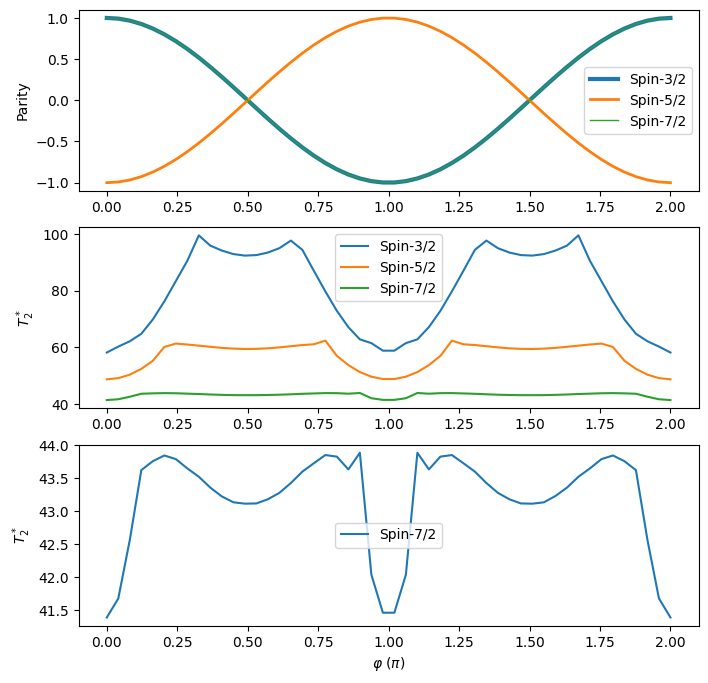

In [934]:
fig, ax = plt.subplots(3,1, figsize=(8, 8), dpi=100)

labels = ['Spin-3/2', 'Spin-5/2', 'Spin-7/2']

for i in range(len(psi0s)):
    ax[0].plot(thetas/np.pi, parity[:, i], label=labels[i], lw=3-i)

for i in range(len(psi0s)):
    ax[1].plot(thetas/np.pi, T2s[:, i]*1e3, label=labels[i])

ax[0].legend()
ax[1].legend()

ax[2].plot(thetas/np.pi, T2s[:, 2]*1e3, label='Spin-7/2')
ax[2].legend()

ax[0].set_ylabel('Parity')
ax[1].set_ylabel(r'$T_2^*$')
ax[2].set_ylabel(r'$T_2^*$')

ax[2].set_xlabel(r'$\varphi$ ($\pi$)')

Text(0.5, 1.0, 'x-cat')

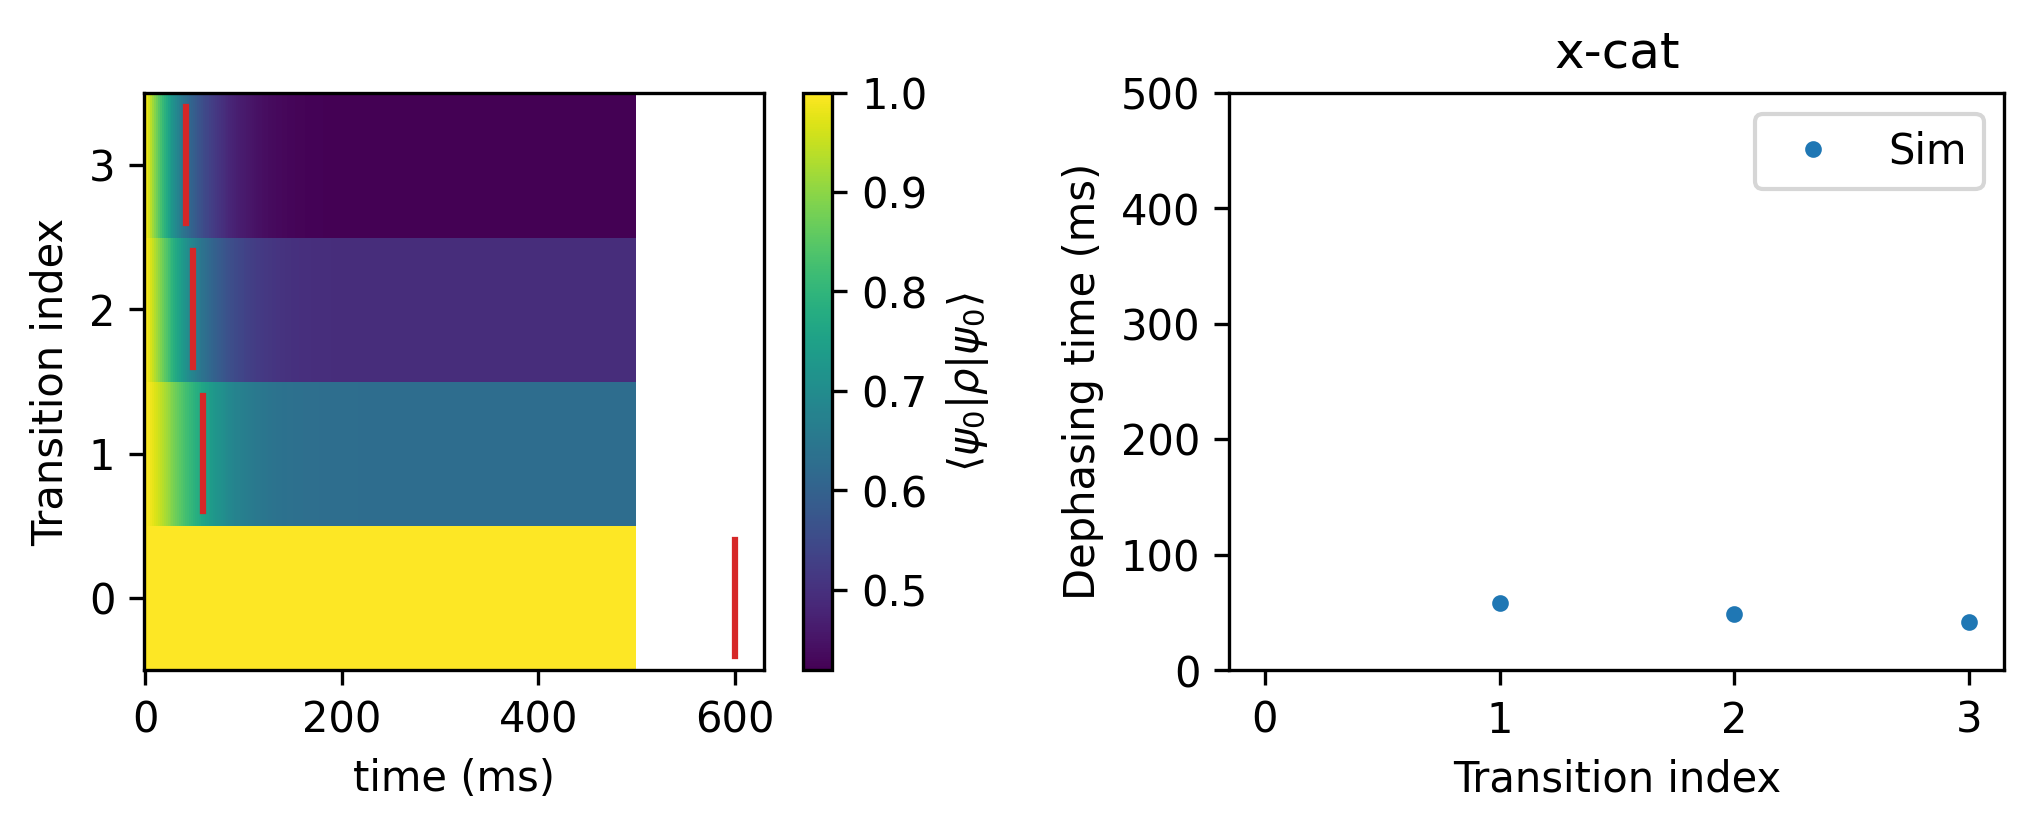

In [869]:
T2s_xdata = np.flip(np.array([46.19, 107.7, 150.8, 233]))*1e-3

plot_free_decay(fidelity, T2s)
plt.title('x-cat')